<a href="https://colab.research.google.com/github/madikabhavana-collab/ores5160-2026/blob/main/FinalProject/Health_DataWarehouse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from datetime import datetime

# Load Dataset 1: Medicare hospital CSV
df_hospital = pd.read_csv("Medicare_IP_Hospitals_by_Provider_and_Service_2024.csv")

# Load Dataset 2: CDC JSON
df_cdc = pd.read_json("CDC PLACES.json")

print("Hospital dataset loaded:", df_hospital.shape)
print("CDC dataset loaded:", df_cdc.shape)

df_hospital.head()

Hospital dataset loaded: (145879, 15)
CDC dataset loaded: (5000, 24)


,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222


In [19]:
cdc = df_cdc.copy()

cdc.columns = cdc.columns.str.lower().str.strip()

cdc['data_value'] = pd.to_numeric(cdc['data_value'], errors='coerce')

In [20]:
# Aggregate CDC data to state level
cdc_state = cdc.groupby('stateabbr')['data_value'].mean().reset_index()

# Rename for merging
cdc_state.rename(columns={
    'stateabbr': 'state',
    'data_value': 'avg_health_indicator'
}, inplace=True)

cdc_state.head()

,state,avg_health_indicator
0,AK,24.463183
1,AL,27.375634
2,AR,27.569102
3,AZ,25.872189
4,CA,24.635387


In [21]:
# Prepare hospital dataset for merging
hospital = df_hospital.copy()

# Standardize hospital column names
hospital.columns = hospital.columns.str.lower().str.strip().str.replace(" ", "_")

# Rename state column to match CDC dataset
hospital.rename(columns={'rndrng_prvdr_state_abrvtn': 'state'}, inplace=True)

hospital[['state', 'tot_dschrgs', 'avg_tot_pymt_amt']].head()

,state,tot_dschrgs,avg_tot_pymt_amt
0,AL,11,103236.272730
1,AL,23,40220.217391
2,AL,13,27305.461538
3,AL,22,31420.954545
4,AL,27,12183.925926


In [22]:
# Merge hospital CSV data with CDC JSON data using state as common key
merged = pd.merge(
    hospital,
    cdc_state,
    on='state',
    how='left'
)

print("Merged dataset shape:", merged.shape)

merged[['state', 'tot_dschrgs', 'avg_tot_pymt_amt', 'avg_health_indicator']].head()

Merged dataset shape: (145879, 16)


,state,tot_dschrgs,avg_tot_pymt_amt,avg_health_indicator
0,AL,11,103236.272730,27.375634
1,AL,23,40220.217391,27.375634
2,AL,13,27305.461538,27.375634
3,AL,22,31420.954545,27.375634
4,AL,27,12183.925926,27.375634


In [23]:
def validate_data(df):
    """
    Runs data quality checks for missing values, duplicate rows,
    invalid discharge counts, payment inconsistencies, and high-charge outliers.
    """
    print("Missing values by column:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())

    invalid_discharges = (df['tot_dschrgs'] <= 0).sum()
    print("\nInvalid discharges (<=0):", invalid_discharges)

    invalid_payments = (df['avg_mdcr_pymt_amt'] > df['avg_tot_pymt_amt']).sum()
    print("Medicare payment greater than total payment:", invalid_payments)

    high_charge_outliers = (df['avg_submtd_cvrd_chrg'] > 100000).sum()
    print("High charge outliers (>100000):", high_charge_outliers)

validate_data(merged)

Missing values by column:
rndrng_prvdr_ccn               0
rndrng_prvdr_org_name          0
rndrng_prvdr_city              0
rndrng_prvdr_st                0
rndrng_prvdr_state_fips        0
rndrng_prvdr_zip5              0
state                          0
rndrng_prvdr_ruca              0
rndrng_prvdr_ruca_desc         0
drg_cd                         0
drg_desc                       0
tot_dschrgs                    0
avg_submtd_cvrd_chrg           0
avg_tot_pymt_amt               0
avg_mdcr_pymt_amt              0
avg_health_indicator       23972
dtype: int64

Duplicate rows: 0

Invalid discharges (<=0): 0
Medicare payment greater than total payment: 0
High charge outliers (>100000): 41637


In [24]:
# Store merged dataset in SQLite database
import sqlite3

conn = sqlite3.connect("hospital_warehouse.db")

merged.to_sql("merged_data", conn, if_exists="replace", index=False)

# Check data
pd.read_sql("SELECT * FROM merged_data LIMIT 10", conn)

,rndrng_prvdr_ccn,rndrng_prvdr_org_name,rndrng_prvdr_city,rndrng_prvdr_st,rndrng_prvdr_state_fips,rndrng_prvdr_zip5,state,rndrng_prvdr_ruca,rndrng_prvdr_ruca_desc,drg_cd,drg_desc,tot_dschrgs,avg_submtd_cvrd_chrg,avg_tot_pymt_amt,avg_mdcr_pymt_amt,avg_health_indicator
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.636360,103236.272730,91218.181818,27.375634
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.086960,40220.217391,37634.565217,27.375634
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.307692,27305.461538,25644.307692,27.375634
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.409090,31420.954545,23270.863636,27.375634
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.555560,12183.925926,10532.222222,27.375634
5,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,39,EXTRACRANIAL PROCEDURES WITHOUT CC/MCC,47,90166.212766,9712.510638,7136.319149,27.375634
6,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,56,DEGENERATIVE NERVOUS SYSTEM DISORDERS WITH MCC,13,65932.000000,16949.000000,14845.769231,27.375634
7,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,57,DEGENERATIVE NERVOUS SYSTEM DISORDERS WITHOUT MCC,20,26026.500000,10431.650000,8639.300000,27.375634
8,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,64,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,74,71396.337838,14841.040541,12331.918919,27.375634
9,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,65,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,62,40065.596774,8402.016129,6009.790323,27.375634


In [25]:
# Create pivot table: total discharges by state
pivot_state = merged.pivot_table(
    values='tot_dschrgs',
    index='state',
    aggfunc='sum'
)

pivot_state.head()

,tot_dschrgs
state,
AK,9804
AL,67132
AR,54526
AZ,96271
CA,462315


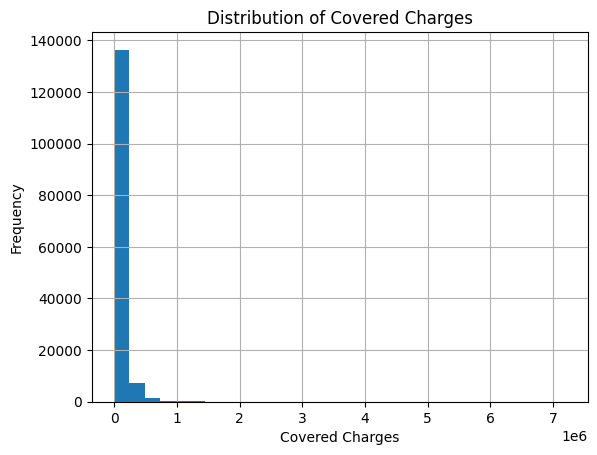

In [26]:
merged['avg_submtd_cvrd_chrg'].hist(bins=30)

plt.title("Distribution of Covered Charges")
plt.xlabel("Covered Charges")
plt.ylabel("Frequency")
plt.show()

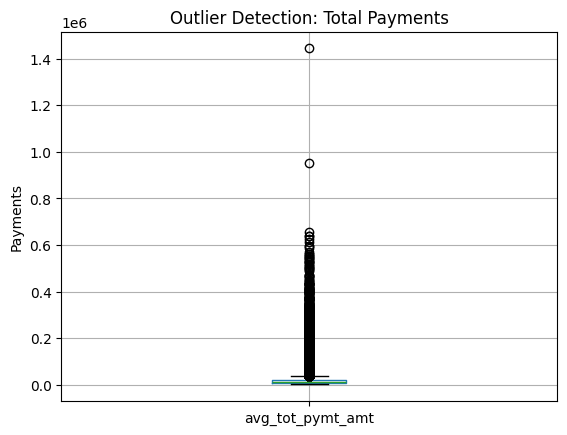

In [27]:
merged.boxplot(column='avg_tot_pymt_amt')

plt.title("Outlier Detection: Total Payments")
plt.ylabel("Payments")
plt.show()

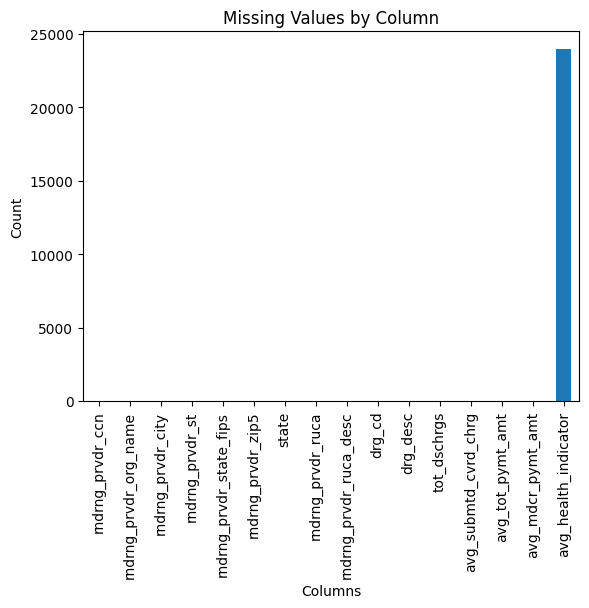

In [28]:
merged.isnull().sum().plot(kind='bar')

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()

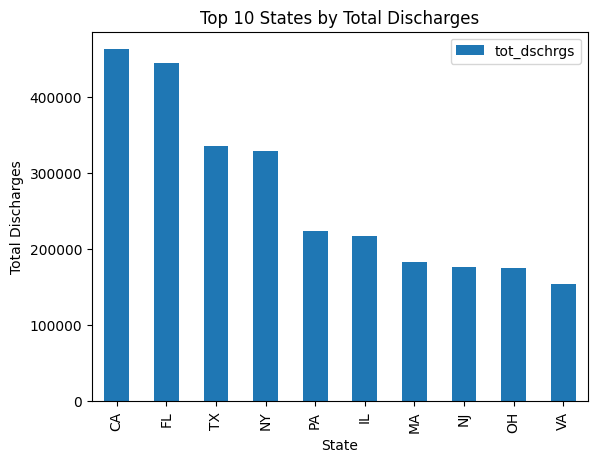

In [29]:
pivot_state.sort_values('tot_dschrgs', ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 States by Total Discharges")
plt.xlabel("State")
plt.ylabel("Total Discharges")
plt.show()